In [6]:
import pandas as pd
df = pd.read_csv('../data/raw/loan.csv', low_memory=False, nrows=100000)
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 145 entries, id to settlement_term
dtypes: float64(58), int64(52), str(35)
memory usage: 126.1 MB


In [7]:
df['loan_status'].value_counts()


loan_status
Current               96793
Fully Paid             2431
Late (31-120 days)      318
In Grace Period         316
Late (16-30 days)       123
Charged Off              19
Name: count, dtype: int64

In [8]:
import pandas as pd

useful_cols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
               'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti',
               'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'loan_status']

chunks = []
for chunk in pd.read_csv('../data/raw/loan.csv', low_memory=False, usecols=useful_cols, chunksize=200000):
    chunks.append(chunk)
    print("Loaded a chunk, total so far:", sum(len(c) for c in chunks))

df_full = pd.concat(chunks, ignore_index=True)
df_full.shape

Loaded a chunk, total so far: 200000
Loaded a chunk, total so far: 400000
Loaded a chunk, total so far: 600000
Loaded a chunk, total so far: 800000
Loaded a chunk, total so far: 1000000
Loaded a chunk, total so far: 1200000
Loaded a chunk, total so far: 1400000
Loaded a chunk, total so far: 1600000
Loaded a chunk, total so far: 1800000
Loaded a chunk, total so far: 2000000
Loaded a chunk, total so far: 2200000
Loaded a chunk, total so far: 2260668


(2260668, 16)

In [9]:
df_full['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [10]:
df_model = df_full[df_full['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_model['default'] = (df_model['loan_status'] == 'Charged Off').astype(int)

print(df_model.shape)
print(df_model['default'].value_counts())

(1303607, 17)
default
0    1041952
1     261655
Name: count, dtype: int64


In [11]:
df_model.to_csv('../data/processed/loan_cleaned.csv', index=False)
print("Saved successfully!")

Saved successfully!


## Target Variable Definition
We kept only loans with a finished outcome: "Fully Paid" (0) and "Charged Off" (1).
Excluded: "Current", "Late", "In Grace Period", "Default" (rare), and "Does not meet credit policy" rows,
since these don't have a confirmed final outcome yet or are too ambiguous.
Final dataset: 1,303,607 rows. Class distribution: 80% paid, 20% defaulted (imbalanced).


In [12]:
df_model.columns.tolist()

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'loan_status',
 'purpose',
 'dti',
 'open_acc',
 'revol_bal',
 'revol_util',
 'total_acc',
 'default']

In [13]:
feature_cols = [col for col in df_model.columns if col not in ['loan_status', 'default']]
print(feature_cols)

['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc']


## Feature Selection & Leakage Check
Reviewed all 15 candidate features — confirmed all are known at loan application time
(no post-outcome information like payments received or recoveries was included, since
we only selected these columns during initial data loading). `loan_status` and `default`
are excluded from features (loan_status is the raw outcome; default is our target).

Final feature list: loan_amnt, term, int_rate, installment, grade, sub_grade, emp_length,
home_ownership, annual_inc, purpose, dti, open_acc, revol_bal, revol_util, total_acc

In [14]:
df_model[feature_cols].isnull().sum()

loan_amnt             0
term                  0
int_rate              0
installment           0
grade                 0
sub_grade             0
emp_length        75454
home_ownership        0
annual_inc            0
purpose               0
dti                 312
open_acc              0
revol_bal             0
revol_util          810
total_acc             0
dtype: int64

In [15]:
df_model['emp_length'] = df_model['emp_length'].fillna('Unknown')
df_model['dti'] = df_model['dti'].fillna(df_model['dti'].median())
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())

# Verify no missing values remain
df_model[feature_cols].isnull().sum()


loan_amnt         0
term              0
int_rate          0
installment       0
grade             0
sub_grade         0
emp_length        0
home_ownership    0
annual_inc        0
purpose           0
dti               0
open_acc          0
revol_bal         0
revol_util        0
total_acc         0
dtype: int64

In [16]:
df_model.to_csv('../data/processed/loan_cleaned.csv', index=False)
print("Updated cleaned dataset saved!")

Updated cleaned dataset saved!


## Missing Value Handling
- emp_length: 75,454 missing (5.8%) → filled with "Unknown" (categorical)
- dti: 312 missing (0.02%) → filled with median
- revol_util: 810 missing (0.06%) → filled with median
All 15 feature columns now have zero missing values.

In [17]:
df_model.to_csv('../data/processed/loan_cleaned.csv', index=False)
print("Saved!")

Saved!


In [18]:
print(df_model['term'].unique())
print(df_model['grade'].unique())
print(df_model['emp_length'].unique())
print(df_model['home_ownership'].unique())
print(df_model['purpose'].unique())

<ArrowStringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str
<ArrowStringArray>
['D', 'C', 'A', 'B', 'E', 'G', 'F']
Length: 7, dtype: str
<ArrowStringArray>
[  '5 years',  '< 1 year', '10+ years',   '3 years',   '4 years',    '1 year',
   '8 years',   'Unknown',   '2 years',   '6 years',   '9 years',   '7 years']
Length: 12, dtype: str
<ArrowStringArray>
['MORTGAGE', 'RENT', 'OWN', 'ANY', 'NONE', 'OTHER']
Length: 6, dtype: str
<ArrowStringArray>
['debt_consolidation',        'credit_card',              'other',
              'house',                'car',   'home_improvement',
             'moving',     'small_business',           'vacation',
            'medical',     'major_purchase',   'renewable_energy',
            'wedding',        'educational']
Length: 14, dtype: str


In [19]:
# Term: extract number
df_model['term'] = df_model['term'].str.extract('(\d+)').astype(int)

# Grade: map to numbers
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df_model['grade'] = df_model['grade'].map(grade_map)

# Emp_length: map to numbers
emp_map = {
    'Unknown': -1, '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8,
    '9 years': 9, '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_map)

# One-hot encode home_ownership and purpose
df_model = pd.get_dummies(df_model, columns=['home_ownership', 'purpose'], drop_first=True)

# Drop sub_grade for now (too granular, grade already captures this info)
df_model = df_model.drop(columns=['sub_grade'])

print(df_model.shape)
df_model.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ramya\AppData\Local\Temp\ipykernel_15036\730895216.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_model['term'] = df_model['term'].str.extract('(\d+)').astype(int)


(1303607, 32)


,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,loan_status,dti,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
100,30000,36,22.35,1151.16,4,5,100000.0,Fully Paid,30.46,11.0,...,False,False,False,False,False,False,False,False,False,False
152,40000,60,16.14,975.71,3,0,45000.0,Fully Paid,50.53,18.0,...,False,False,False,False,False,False,False,False,False,False
170,20000,36,7.56,622.68,1,10,100000.0,Fully Paid,18.92,9.0,...,False,False,False,False,False,False,False,False,False,False
186,4500,36,11.31,147.99,2,10,38500.0,Fully Paid,4.64,12.0,...,False,False,False,False,False,False,False,False,False,False
215,8425,36,27.27,345.18,5,3,450000.0,Fully Paid,12.37,21.0,...,False,False,False,False,False,False,False,False,False,False


In [20]:
feature_cols = [col for col in df_model.columns if col not in ['loan_status', 'default']]
print(len(feature_cols), "features")

df_model.to_csv('../data/processed/loan_encoded.csv', index=False)
print("Saved encoded dataset!")

30 features
Saved encoded dataset!


In [21]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())


Train shape: (1042885, 30)
Test shape: (260722, 30)
Train default rate: 0.20071628223629642
Test default rate: 0.20071570485037704


In [22]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print("All splits saved!")

All splits saved!


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_model.fit(X_train, y_train)

preds = baseline_model.predict(X_test)
probs = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

c:\Users\ramya\credit-risk-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.87      0.62      0.73    208391
           1       0.30      0.64      0.41     52331

    accuracy                           0.63    260722
   macro avg       0.59      0.63      0.57    260722
weighted avg       0.76      0.63      0.66    260722

ROC-AUC: 0.6770613720305553


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=2000, class_weight='balanced')
baseline_model.fit(X_train_scaled, y_train)

preds = baseline_model.predict(X_test_scaled)
probs = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76    208391
           1       0.32      0.62      0.42     52331

    accuracy                           0.66    260722
   macro avg       0.60      0.65      0.59    260722
weighted avg       0.76      0.66      0.69    260722

ROC-AUC: 0.7019768162889983


In [25]:
import joblib

joblib.dump(baseline_model, '../models/baseline_logistic.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Baseline model saved!")

Baseline model saved!


In [26]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

results = {}

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = roc_auc_score(y_test, rf_probs)
print("Random Forest ROC-AUC:", results['Random Forest'])

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = roc_auc_score(y_test, xgb_probs)
print("XGBoost ROC-AUC:", results['XGBoost'])

print(results)

Random Forest ROC-AUC: 0.6993425411950078
XGBoost ROC-AUC: 0.7150491574300467
{'Random Forest': 0.6993425411950078, 'XGBoost': 0.7150491574300467}


In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

best_model = search.best_estimator_
best_probs = best_model.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, best_probs))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.7171989418677086
Test ROC-AUC: 0.7156577782626861


In [28]:
import joblib

joblib.dump(best_model, '../models/credit_risk_model.pkl')
joblib.dump(feature_cols, '../models/feature_columns.pkl')
print("Final model saved!")

Final model saved!


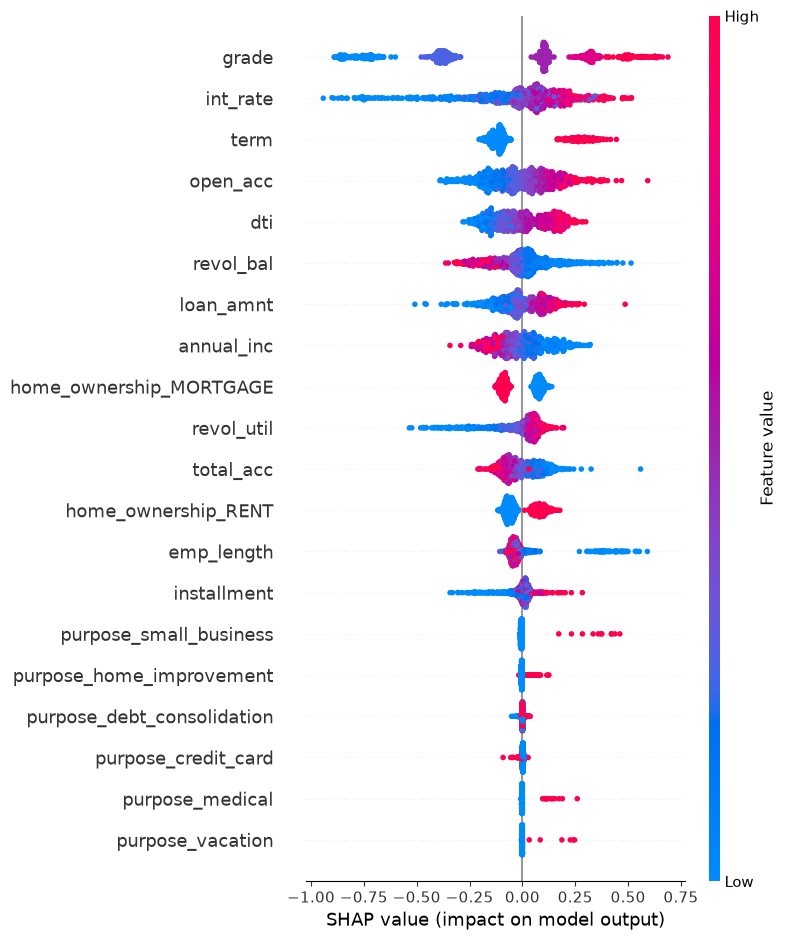

In [29]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])  # sample 1000 rows for speed

shap.summary_plot(shap_values, X_test.iloc[:1000], show=False)

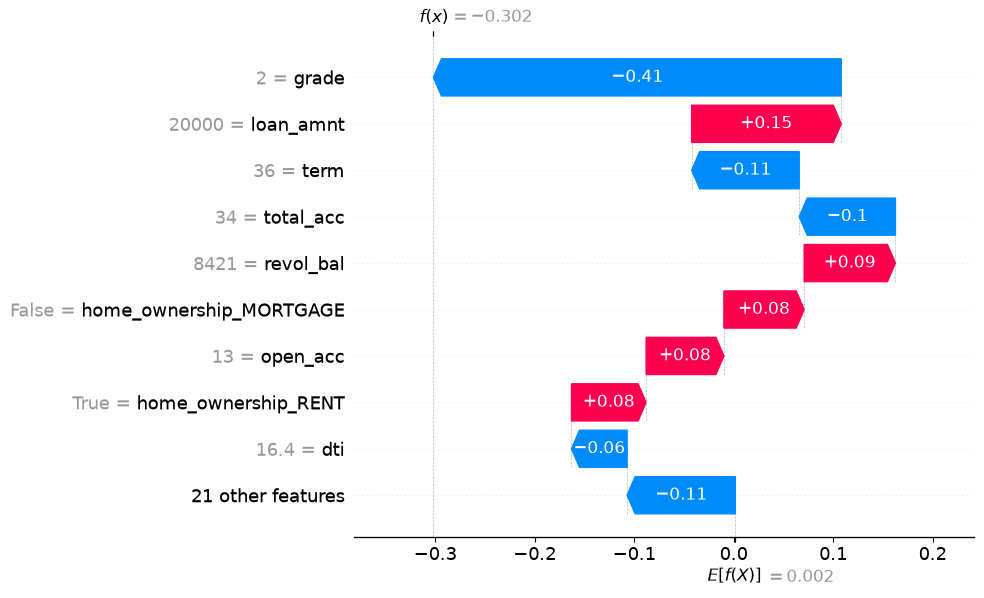

In [30]:
shap.plots.waterfall(explainer(X_test.iloc[[0]])[0])